# Gaussian Mixture Model Thresholding

This notebook demonstrates the `GMMThresholding` class from the `cc_mapping` package, which provides a flexible, semi-supervised approach to categorizing samples based on continuous features using Gaussian Mixture Models (GMMs).

## Key Features

- **Automatic threshold determination**: Fit GMMs and automatically calculate decision boundaries
- **Manual threshold override**: Specify custom thresholds while leveraging GMM visualization
- **Label collapsing**: Fit many GMM components for adaptive boundaries, then collapse to fewer categories
- **Exploratory visualization**: Explore data distributions before committing to thresholding
- **Comprehensive visualization**: Multiple plotting methods to understand your data and thresholds

In [20]:
# Import all required libraries
from pathlib import Path
from urllib.request import urlretrieve

import anndata as ad
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import sys

sys.path.append("R:\Dante\git\cc_mapping\src")

from cc_mapping.thresholding import GMMThresholding
from cc_mapping.utils import create_boolean_label_combination

%matplotlib inline

---

## Setup and Data Loading

In [22]:
# Create results directory structure for saving figures
results_dir = cwd / "results"
single_results_dir = results_dir / "single"

# Create directories if they don't exist
results_dir.mkdir(exist_ok=True)
single_results_dir.mkdir(exist_ok=True)

print(f"Results directory created at: {results_dir}")
print(f"Single threshold results directory: {single_results_dir}")

Results directory created at: c:\Users\dap182\Documents\git\cc_mapping\notebooks\results
Single threshold results directory: c:\Users\dap182\Documents\git\cc_mapping\notebooks\results\single


In [21]:
url = "https://zenodo.org/records/4525425/files/control_manifold_allfeatures.csv?download=1"

cwd = Path.cwd()

download_path = cwd / "data" / "control_manifold_allfeatures.csv"

if not download_path.parent.exists():
    download_path.parent.mkdir(parents=True)
    urlretrieve(url, download_path)

In [23]:
csv = pd.read_csv(download_path, index_col=0, low_memory=False)
csv.index = csv.index.astype(str)
csv.head()

,E2F1 (nuc median),cycA (nuc median),cycD1 (nuc median),p21 (nuc median),Int_Intg_DNA_nuc,Skp2 (nuc median),Cdt1 (nuc median),Nuc area,Cdh1 (nuc median),cycE (nuc median),...,STAT3 (phospho/total nuc),age,phase,PHATE_1,PHATE_2,PCNA foci,DNA content,Local cell density,annotated age,annotated phase
Unnamed: 0.1.1,,,,,,,,,,,,,,,,,,,,,
0,0.006851,0.005875,0.019471,0.026032,5.746899,0.006493,0.005158,553.0,0.014336,0.009262,...,1.770186,10.263173,G1,-0.020654,0.007907,0.005151,2.298759,7.0,NaN,NaN
1,0.012360,0.028153,0.007462,0.004318,8.852262,0.022797,0.005951,490.0,0.015229,0.008392,...,1.455814,12.109644,S,0.025945,-0.000735,0.006861,3.540905,1.0,NaN,NaN
2,0.007279,0.005707,0.006592,0.003632,4.951003,0.015366,0.004929,363.0,0.005730,0.009117,...,1.290323,4.954907,G1,0.002961,-0.004575,0.004148,1.980401,6.0,NaN,NaN
3,0.006531,0.016602,0.009369,0.006264,10.466743,0.019196,0.005234,579.0,0.009361,0.007118,...,1.435065,13.424587,G2,0.034884,0.002944,0.002457,4.186697,9.0,NaN,NaN
5,0.006744,0.006027,0.009033,0.005295,5.249119,0.010422,0.007797,296.0,0.008896,0.007767,...,1.266304,1.828240,G1,-0.019039,0.000584,0.003277,2.099648,3.0,NaN,NaN


In [24]:
# convert the dataframe into an anndata object
# ensure the data is not of object type (e.g. contains strings)
adata = ad.AnnData(
    X=csv.values[:,:-10].astype(np.float32),
)
adata.var_names = csv.columns.values[:-10]

In [25]:
list(adata.var_names)[:3]

['E2F1 (nuc median)', 'cycA (nuc median)', 'cycD1 (nuc median)']

---

## Exploratory Data Analysis

Before performing GMM thresholding, explore your data distribution to:
- Understand the shape of your data distribution
- Decide how many GMM components to use
- Determine appropriate manual threshold values
- Identify potential data quality issues

### Initialize for Exploration

In [45]:
# Initialize the GMM thresholding object for exploration
# Note: We don't need to fit() or categorize_samples() yet for exploratory plots
gmm_explore = GMMThresholding(
    adata=adata, 
    feature='cycD1 (nuc median)',
    label_obs_save_str='cell_cycle_explore'
)

### Histogram Distribution

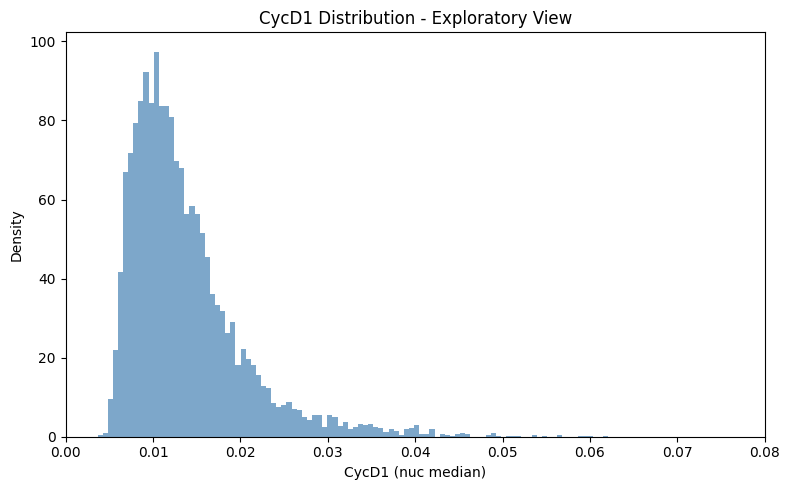

In [46]:
# Plot histogram without any thresholding
fig, ax = plt.subplots(figsize=(8, 5))

gmm_explore.plot_feature_distribution_exploratory(
    hist_kwargs={'bins': 100, 'color': 'steelblue', 'alpha': 0.7},
    x_axis_limits=(0, 0.08),
    ax=ax
)

ax.set_title('CycD1 Distribution - Exploratory View')
ax.set_xlabel('CycD1 (nuc median)')
ax.set_ylabel('Density')
plt.tight_layout()
plt.show()

### Strip Plot with Density

C:\Users\dap182\AppData\Local\Temp\ipykernel_20852\3371904513.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


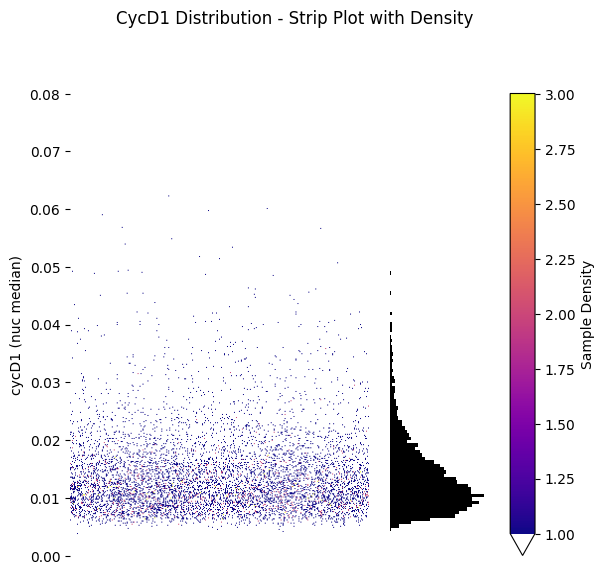

In [ ]:
# Plot strip plot with density coloring (no thresholding yet)
fig, (ax_strip, ax_hist) = gmm_explore.plot_feature_strip_plot_exploratory(
    scatter_density=True,
    x_axis_limits=(0, 0.08),
    hist_kwargs={'bins': 100, 'color': 'black'},
)

plt.suptitle('CycD1 Distribution - Strip Plot with Density', y=1.02)
plt.tight_layout()
plt.show()

The optimal number of components is 2


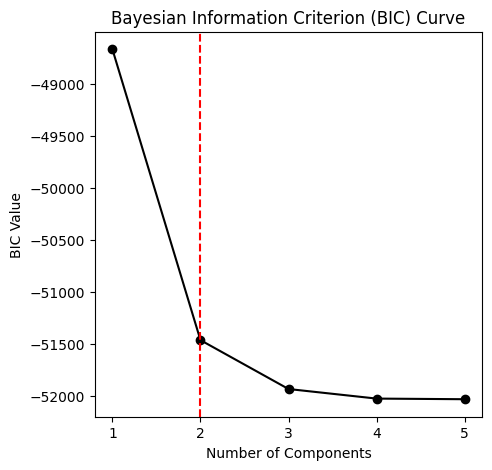

In [ ]:
# initialize the gmm thresholding object with the adata object and the feature of interest
gmm_kwargs = {'init_params': 'k-means++', 'n_init':10, 'max_iter':1000}

gmm_thresholding = GMMThresholding(adata= adata, 
                                    feature = 'cycD1 (nuc median)',
                                    label_obs_save_str= 'Low/High DNA Content',
                                    gmm_kwargs = gmm_kwargs)

# plot the bayesian information criterion curve to determine the optimal number of components
component_range = 5
gmm_thresholding.plot_bayesian_information_criterion_curve(
    component_range=component_range,
)

# the optimal number of components can be calculated without plotting as well
optimal_component_number = gmm_thresholding.determine_optimal_number_components(component_range=component_range)
print(f'The optimal number of components is {optimal_component_number}')

#fit the GMM with the optimal number of components
gmm_thresholding.fit(n_components=optimal_component_number)

---

## Automatic Thresholding

The standard workflow:
1. Determine optimal number of GMM components using BIC
2. Fit the GMM with the optimal number of components
3. Categorize samples using automatically calculated decision boundaries

In [30]:
# Categorize samples using automatically calculated decision boundaries from the fitted GMM
# The ordered_labels parameter specifies the labels from low to high feature values
gmm_thresholding.categorize_samples(ordered_labels=['Low', 'High'])

Figure saved to: c:\Users\dap182\Documents\git\cc_mapping\notebooks\results\single\basic_threshold_histogram.png


<Axes: title={'center': 'cycD1 (nuc median)'}, xlabel='cycD1 (nuc median)', ylabel='Density'>

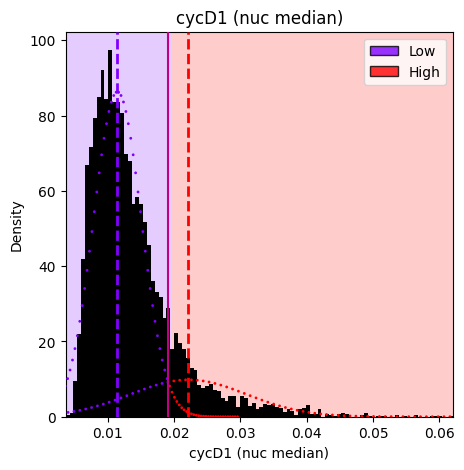

In [31]:

gmm_thresholding.plot_hist_distribution_with_boundaries(
    save_path=single_results_dir / 'basic_threshold_histogram.png'  # Optional: save the figure
)

### Visualize Results

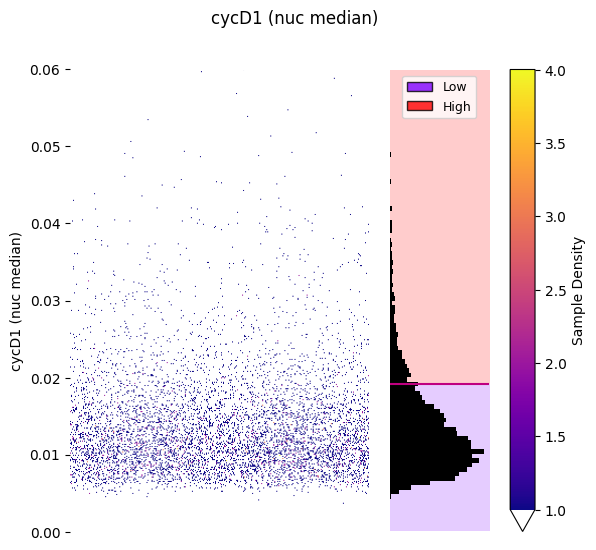

In [32]:
#plots a strip plot with the labeled histogram and the decision boundaries, coloring by sample density
hist_kwargs = {"bins": 100, 'color': 'black'}
# Note: vmax is set to match the exploratory plot's auto-calculated range for consistent colorbars
gmm_thresholding.plot_strip_plot_histogram_with_decision_boundaries(hist_kwargs=hist_kwargs, vmax=4, y_axis_limits=(0,0.06));

Strip plot colored by sample density:

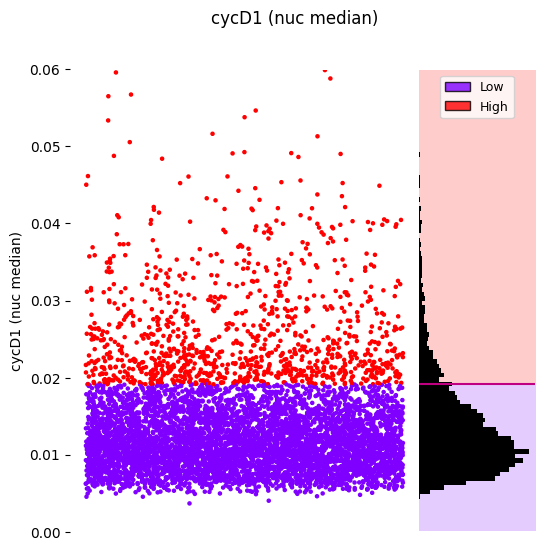

In [33]:
#plots a strip plot with the labeled histogram and the decision boundaries, coloring by sample labels
hist_kwargs = {"bins": 100, 'color': "black"}
gmm_thresholding.plot_strip_plot_histogram_with_decision_boundaries(y_axis_limits=(0,0.06),
                                                                    hist_kwargs=hist_kwargs,
                                                                    scatter_density=False,
                                                                    );

Or colored by assigned labels:

---

## Manual Thresholding

Override automatically calculated thresholds by specifying `manual_thresholds`. This is useful for applying consistent thresholds across datasets or using domain-specific cutoff values.

<Axes: title={'center': 'cycD1 (nuc median)'}, xlabel='cycD1 (nuc median)', ylabel='Density'>

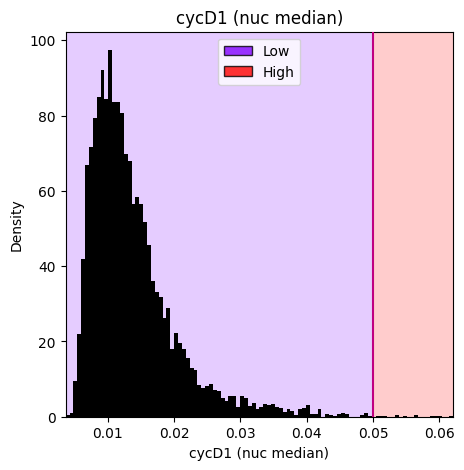

In [34]:
# Reinitialize to demonstrate manual thresholds
gmm_thresholding_manual = GMMThresholding(
    adata=adata, 
    feature='cycD1 (nuc median)',
    label_obs_save_str='Manual Low/High DNA Content',
    gmm_kwargs=gmm_kwargs
)

# Fit the GMM (still useful for visualization even when using manual thresholds)
gmm_thresholding_manual.fit(n_components=optimal_component_number)

# Categorize with manual threshold at 0.05
# The manual_thresholds parameter overrides automatic boundary calculation
gmm_thresholding_manual.categorize_samples(
    ordered_labels=['Low', 'High'], 
    manual_thresholds=[0.05]
)

# Visualize to see the manually set threshold
gmm_thresholding_manual.plot_hist_distribution_with_boundaries(resolution=100)

---

## Results and Utilities

In [35]:
adata = gmm_thresholding.return_adata()
adata

AnnData object with n_obs × n_vars = 6797 × 289
    obs: 'Low/High DNA Content'
    uns: 'gmm_thresholding_events'

Thresholding metadata is stored in `adata.uns['gmm_thresholding_events']`.

---

### Utility Functions
---

#### Generate Thresholding Report

In [36]:
# Generate a text report using the method from the base class
report = gmm_thresholding.generate_thresholding_report(
    output_format='text'
)
print(report)

Thresholding Report

1. cycD1 (nuc median) (Standard Thresholding)
---------------------------------------------
   Feature: cycD1 (nuc median)
   Layer: None
   Obs column: Low/High DNA Content
   Components: 2
   Thresholds: [0.0191]
   Labels: ['Low', 'High']
   Cell counts: Low=5744, High=1053

Total operations: 1
Operation types:
  - standard: 1


Or as a DataFrame:

In [37]:
# Generate a DataFrame report
report_df = gmm_thresholding.generate_thresholding_report(
    output_format='dataframe'
)
display(report_df)

,Operation,Type,Feature,Layer,Obs Label,Components,Thresholds,Labels,Parent,Refined From,Total Cells
0,1. cycD1 (nuc median),standard,cycD1 (nuc median),None,Low/High DNA Content,2,0.0191,"Low, High",None,N/A,6797


---

#### Boolean Label Combination

Combine categorical labels with boolean operators (AND, OR, XOR) for advanced filtering.

In [38]:
# Create a synthetic treatment label for demonstration
np.random.seed(42)
n_cells = len(adata)
adata.obs['treatment'] = pd.Categorical(
    np.random.choice(['control', 'drug_A', 'drug_B'], size=n_cells)
)

# Combine two categorical labels using boolean operators
# operator options: 'AND', 'OR', 'XOR'
# Note: Parameter names have changed - use obs_key_1, match_values_1, etc.
adata = create_boolean_label_combination(
    adata,
    obs_key_1='treatment',
    match_values_1=['control'],
    obs_key_2='Low/High DNA Content',
    match_values_2=['High'],
    operator='AND',  
    output_obs_key='control_and_high_DNA',
    true_label='control_with_high_DNA',
    false_label='other',
    overwrite=False  # Default: raises error if output_obs_key already exists
)

print("Combined label distribution:")
print(adata.obs['control_and_high_DNA'].value_counts())

Combined label distribution:
control_and_high_DNA
other                    6455
control_with_high_DNA     342
Name: count, dtype: int64
